# Fetch data from ReqMgr2 and MSRuleCleaner and classify by Tape endpoint

In [8]:

import json
import requests
import urllib3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pprint import pprint

In [2]:

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

myCert = "/Users/amaltar2/Devel/DockerWMCore/certs/servicecert.pem"
myKey = "/Users/amaltar2/Devel/DockerWMCore/certs/servicekey.pem"

In [3]:
reqmgr_url="https://cmsweb-prod.cern.ch/reqmgr2/data/request"
headers = {"Content-type": "application/json", "Accept": "application/json"}
params = {"status": "announced", "detail": "false"}

wflows = requests.get(reqmgr_url, params=params, headers=headers, cert=(myCert, myKey), verify=False)
if wflows.ok is True:
    wflows = wflows.json()['result']
else:
    print(f"Error fetching data for workflow {wflows.status_code}")
    exit(1)

print(f"Found {len(wflows)} workflows in announced state")
print(f"First 10 workflows: {wflows[:10]}")

Found 10709 workflows in announced state
First 10 workflows: ['pdmvserv_Run2017C_Charmonium_UL2017_MiniAODv2_BParking_230917_123415_3906', 'cmsunified_task_EXO-Run3Summer23wmLHEGS-02748__v1_T_250320_000414_4593', 'cmsunified_task_EXO-RunIISummer20UL17wmLHEGEN-06381__v1_T_241201_235609_8841', 'cmsunified_task_EXO-Run3Summer23BPixwmLHEGS-02410__v1_T_250312_224613_6406', 'cmsunified_task_B2G-Run3Summer23BPixwmLHEGS-02774__v1_T_250130_215735_4774', 'cmsunified_task_TOP-RunIISummer20UL16wmLHEGEN-00762__v1_T_231101_162355_6156', 'cmsunified_task_B2G-Run3Summer23wmLHEGS-04051__v1_T_250205_224151_7749', 'cmsunified_task_EXO-Run3Summer22wmLHEGS-03862__v1_T_250319_122314_4274', 'cmsunified_task_B2G-RunIISummer20UL16wmLHEGENAPV-07766__v1_T_250131_134212_533', 'cmsunified_task_B2G-RunIISummer20UL17wmLHEGEN-07474__v1_T_250221_215950_1607']


In [4]:
# This JSON was colleted by a different script 
with open("msoutput_data.json", "r") as jo:
    msoutput_data = json.load(jo)

## Histogram of number of workflows per Tape destination

In [5]:
pprint(msoutput_data[0])

{'microservice': 'MSManager',
 'microservice_version': '2.3.10.3',
 'request': 'cmsunified_task_EXO-Run3Summer23BPixwmLHEGS-03005__v1_T_250319_234858_8083',
 'transferDoc': {'Campaign': 'Run3Summer23BPixwmLHEGS',
                 'CreationTime': 1743676674,
                 'IsRelVal': False,
                 'LastUpdate': 1743678052,
                 'OutputDatasets': ['/WminusH_Hto2Sto4Tau_ctauS-1000_MH-125_MS-7_TuneCP5_13p6TeV_powheg-pythia8/Run3Summer23BPixDRPremix-130X_mcRun3_2023_realistic_postBPix_v6-v2/AODSIM',
                                    '/WminusH_Hto2Sto4Tau_ctauS-1000_MH-125_MS-7_TuneCP5_13p6TeV_powheg-pythia8/Run3Summer23BPixMiniAODv4-130X_mcRun3_2023_realistic_postBPix_v6-v2/MINIAODSIM',
                                    '/WminusH_Hto2Sto4Tau_ctauS-1000_MH-125_MS-7_TuneCP5_13p6TeV_powheg-pythia8/Run3Summer23BPixNanoAODv12-130X_mcRun3_2023_realistic_postBPix_v6-v2/NANOAODSIM'],
                 'OutputMap': [{'Campaign': 'Run3Summer23BPixDRPremix',
               

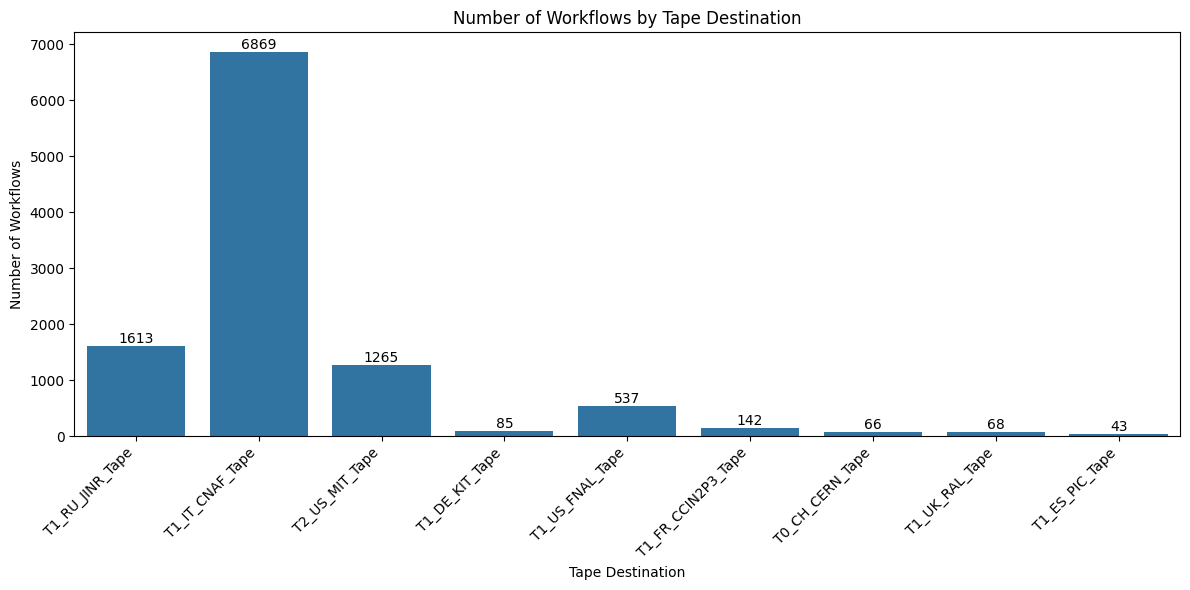


Raw counts by Tape Destination:
{'T1_RU_JINR_Tape': 1613, 'T1_IT_CNAF_Tape': 6869, 'T2_US_MIT_Tape': 1265, 'T1_DE_KIT_Tape': 85, 'T1_US_FNAL_Tape': 537, 'T1_FR_CCIN2P3_Tape': 142, 'T0_CH_CERN_Tape': 66, 'T1_UK_RAL_Tape': 68, 'T1_ES_PIC_Tape': 43}


In [6]:
by_tape = {}
for wflow in msoutput_data:
    for dset in wflow['transferDoc']['OutputMap']:
        if dset['TapeDestination']:
            by_tape.setdefault(dset['TapeDestination'], 0)
            by_tape[dset['TapeDestination']] += 1
            break


# Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(x=by_tape.keys(), y=by_tape.values())

# Customize the plot
plt.title('Number of Workflows by Tape Destination')
plt.xlabel('Tape Destination')
plt.ylabel('Number of Workflows')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add value labels on top of each bar
for i, v in enumerate(by_tape.values()):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

# Print the raw counts
print("\nRaw counts by Tape Destination:")
print(by_tape)

## Histogram of number of rules grouped by Tape destination

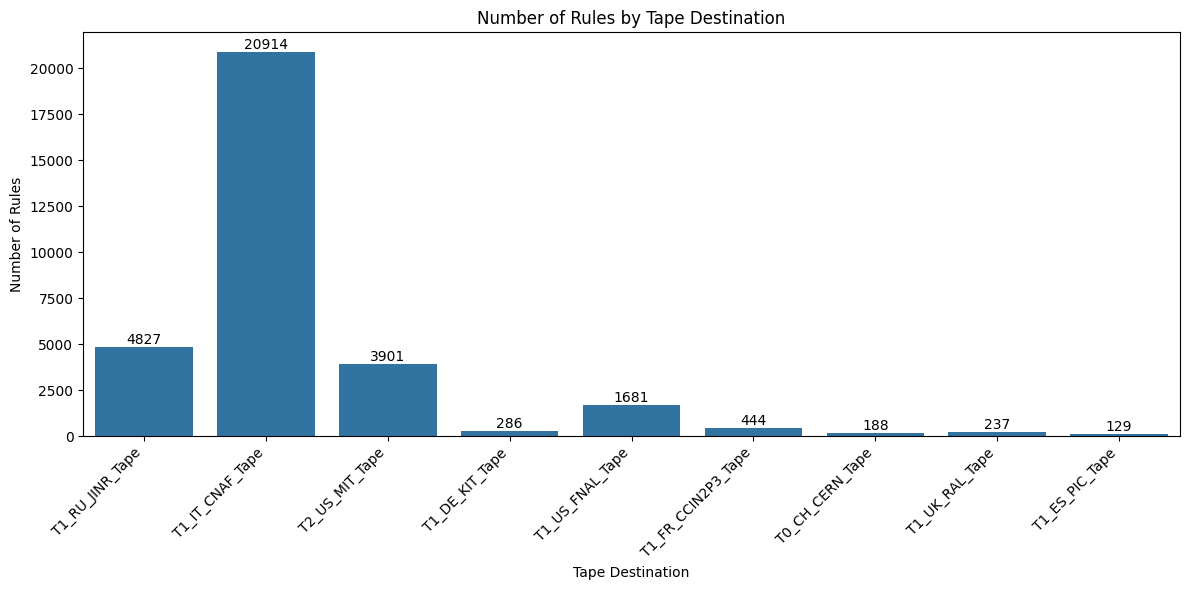


Raw counts by Tape Destination:
{'T1_RU_JINR_Tape': 4827, 'T1_IT_CNAF_Tape': 20914, 'T2_US_MIT_Tape': 3901, 'T1_DE_KIT_Tape': 286, 'T1_US_FNAL_Tape': 1681, 'T1_FR_CCIN2P3_Tape': 444, 'T0_CH_CERN_Tape': 188, 'T1_UK_RAL_Tape': 237, 'T1_ES_PIC_Tape': 129}


In [7]:
dset_by_tape = {}
for wflow in msoutput_data:
    for dset in wflow['transferDoc']['OutputMap']:
        if dset['TapeDestination']:
            dset_by_tape.setdefault(dset['TapeDestination'], 0)
            dset_by_tape[dset['TapeDestination']] += 1


# Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(x=dset_by_tape.keys(), y=dset_by_tape.values())

# Customize the plot
plt.title('Number of Rules by Tape Destination')
plt.xlabel('Tape Destination')
plt.ylabel('Number of Rules')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add value labels on top of each bar
for i, v in enumerate(dset_by_tape.values()):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

# Print the raw counts
print("\nRaw counts by Tape Destination:")
print(dset_by_tape)

## Distribution by MSOutput document creation time

/var/folders/ry/pr0j_gnj06j2ks3pm_44vq1c0000gq/T/ipykernel_34511/746240664.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  bins = pd.date_range(start=min_date.replace(day=1),


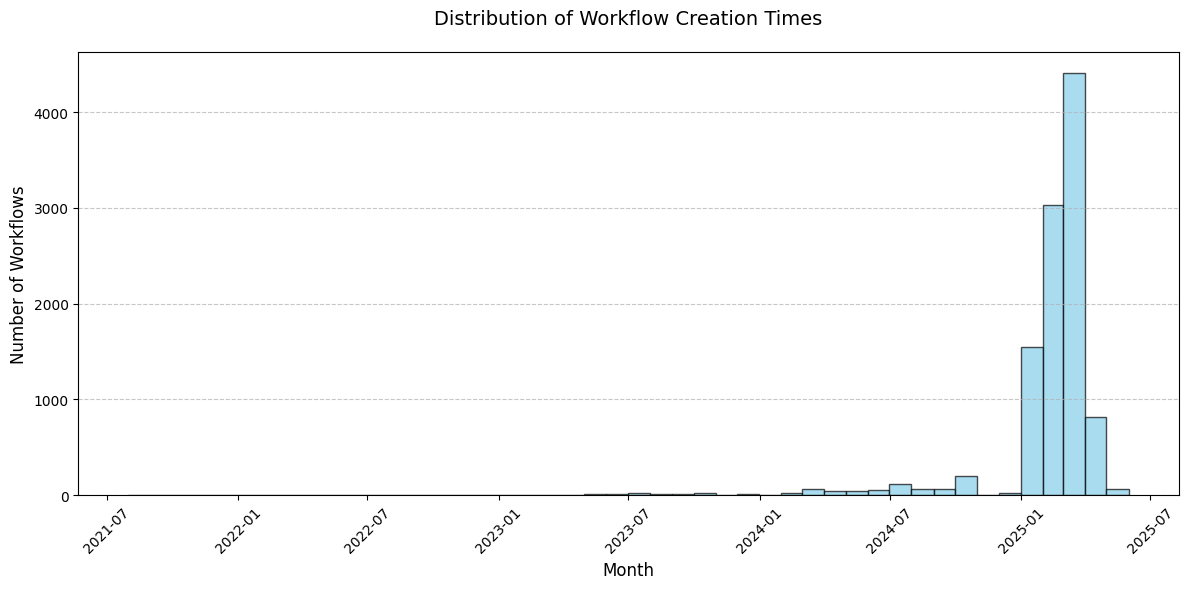

In [11]:
creation_times = []
for wflow in msoutput_data:
    creation_time = datetime.fromtimestamp(wflow['transferDoc']['CreationTime'])
    creation_times.append(creation_time)

# Convert to pandas Series for easier handling
creation_times_series = pd.Series(creation_times)
    
# Create the plot
plt.figure(figsize=(12, 6))

# Create monthly bins
# First, get the date range
min_date = creation_times_series.min()
max_date = creation_times_series.max()

# Create monthly bins
bins = pd.date_range(start=min_date.replace(day=1), 
                    end=max_date.replace(day=1) + pd.DateOffset(months=1),
                    freq='M')

# Plot histogram with monthly bins
plt.hist(creation_times_series, bins=bins, color='skyblue', edgecolor='black', alpha=0.7)

# Customize the plot
plt.title('Distribution of Workflow Creation Times', fontsize=14, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Workflows', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add grid for better readability
plt.grid(True, axis='y', linestyle='--', alpha=0.7)    

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the plot
#plt.savefig('workflow_creation_time_distribution.png', dpi=300, bbox_inches='tight')
#plt.close()


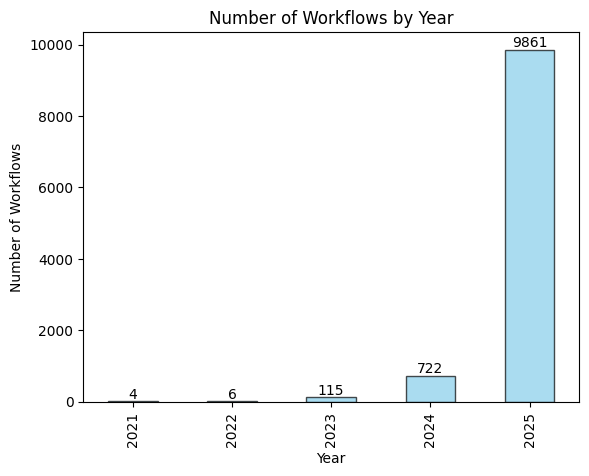

In [14]:
# print number of workflows for each year (add the value on top of each bar)
creation_times_series.dt.year.value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Number of Workflows by Year')
plt.xlabel('Year')
plt.ylabel('Number of Workflows')
for i, v in enumerate(creation_times_series.dt.year.value_counts().sort_index().values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()
